# 1. Introduction

Interest rates play a crucial role in financial markets, influencing the pricing of bonds, loans, derivatives, and many other financial instruments. As a result, accurately modeling the behavior of interest rates is an important problem in quantitative finance.

One of the most widely used approaches for modeling interest rate dynamics is the Cox-Ingersoll-Ross (CIR) model, a short-rate model that assumes interest rates follow a mean-reverting stochastic process. A key advantage of the CIR framework is its ability to model non-negative interest rates while maintaining analytical tractability.

The objective of this project is to implement and evaluate the CIR model using historical yield curve data. The model is calibrated using the 3-Month yield as a proxy for the short-term interest rate and is then used to reconstruct yields for longer maturities. The reconstructed yields are compared with actual market observations to assess the model's predictive performance.

Through this analysis, the project aims to evaluate how effectively a single-factor short-rate model can capture the dynamics of the yield curve and identify the situations in which its assumptions become restrictive.


# 2. Dataset Description

The dataset consists of historical zero-coupon yield observations across multiple maturities of the yield curve. The data is divided into a training set for model calibration and a test set for out-of-sample evaluation.

Each row corresponds to a single observation date, while each column represents the yield associated with a specific maturity.

| Column Name | Maturity |
| ----------- | -------- |
| ZC025YR     | 3 Months |
| ZC050YR     | 6 Months |
| ZC075YR     | 9 Months |
| ZC100YR     | 1 Year   |
| ZC200YR     | 2 Years  |
| ZC500YR     | 5 Years  |
| ZC1000YR    | 10 Years |
| ZC2000YR    | 20 Years |
| ZC3000YR    | 30 Years |

The training dataset contains 1,976 observations covering all maturities. During prediction, only the 3-Month yield is provided as input, and the objective is to reconstruct yields for longer maturities using the calibrated CIR model.


In [ ]:
import pandas as pd

train_df = pd.read_csv(
    "https://raw.githubusercontent.com/Grivann/FinClubPS1/main/train_data.csv"
)

test_df = pd.read_csv(
    "https://raw.githubusercontent.com/Grivann/FinClubPS1/main/test_data.csv"
)

test_3m_df = pd.read_csv(
    "https://raw.githubusercontent.com/Grivann/FinClubPS1/main/test_data_3M.csv"
)

train_df['Date'] = pd.to_datetime(train_df['Date'])
test_df['Date'] = pd.to_datetime(test_df['Date'])
test_3m_df['Date'] = pd.to_datetime(test_3m_df['Date'])

print("Train Shape:", train_df.shape)
print("Test Shape:", test_df.shape)
print("Test 3M Shape:", test_3m_df.shape)

train_df.head()

Train Shape: (1976, 10)
Test Shape: (495, 6)
Test 3M Shape: (495, 2)


,Date,ZC025YR,ZC050YR,ZC075YR,ZC100YR,ZC200YR,ZC500YR,ZC1000YR,ZC2000YR,ZC3000YR
0,2016-05-19,0.005283,0.005640,0.005846,0.006051,0.006146,0.007912,0.014099,0.021224,0.020492
1,2016-05-20,0.005286,0.005642,0.005848,0.006053,0.006176,0.007922,0.014179,0.021353,0.020625
2,2016-05-24,0.005298,0.005651,0.005856,0.006062,0.006228,0.008108,0.014379,0.021534,0.020793
3,2016-05-25,0.005351,0.005603,0.005809,0.006014,0.006281,0.008323,0.014548,0.021596,0.020855
4,2016-05-26,0.005354,0.005605,0.005811,0.006016,0.006115,0.007934,0.013937,0.021326,0.020591


# 3. Data Cleaning

Before proceeding with model development, the dataset was inspected for missing values, duplicate records, inconsistent data types, and potential outliers. Ensuring data quality is an important prerequisite for reliable parameter estimation and forecasting.

The following checks were performed:

- Missing value analysis
- Duplicate row detection
- Data type verification
- Summary statistics inspection
- Outlier identification using boxplots

Training Data Shape: (1976, 10)

Data Types:
Date         datetime64[ns]
 ZC025YR            float64
 ZC050YR            float64
 ZC075YR            float64
 ZC100YR            float64
 ZC200YR            float64
 ZC500YR            float64
 ZC1000YR           float64
 ZC2000YR           float64
 ZC3000YR           float64
dtype: object

Missing Values:
Date         0
 ZC025YR     0
 ZC050YR     0
 ZC075YR     0
 ZC100YR     0
 ZC200YR     0
 ZC500YR     0
 ZC1000YR    0
 ZC2000YR    0
 ZC3000YR    0
dtype: int64

Duplicate Rows:
0
Minimum Yield in Dataset: 0.0004864
Maximum Yield in Dataset: 0.0549405


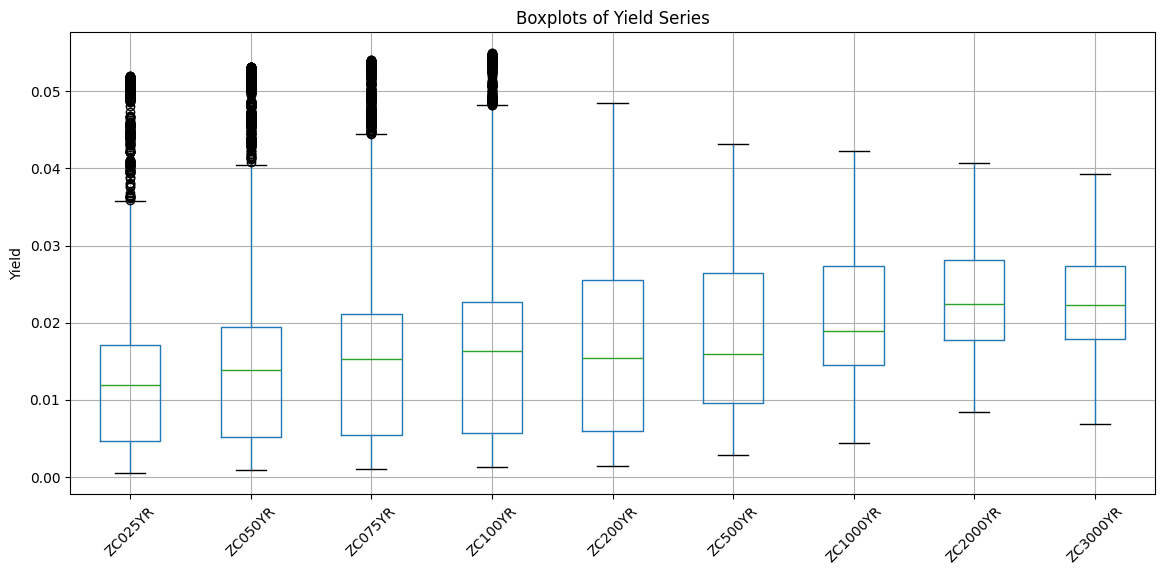

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Training Data Shape:", train_df.shape)
print("\nData Types:")
print(train_df.dtypes)

print("\nMissing Values:")
print(train_df.isnull().sum())

print("\nDuplicate Rows:")
print(train_df.duplicated().sum())

train_df.describe().T

# Check for impossible values
print("Minimum Yield in Dataset:", train_df.iloc[:,1:].min().min())
print("Maximum Yield in Dataset:", train_df.iloc[:,1:].max().max())

# plt.figure(figsize=(10,4))
# sns.heatmap(train_df.isnull(), cbar=False)
# plt.title("Missing Value Heatmap")
# plt.show()
train_df.columns = train_df.columns.str.lstrip()
test_df.columns = test_df.columns.str.lstrip()
test_3m_df.columns = test_3m_df.columns.str.lstrip()



plt.figure(figsize=(14,6))
train_df.boxplot(rot=45)
plt.title("Boxplots of Yield Series")
plt.ylabel("Yield")
plt.show()

### Data Cleaning Summary

The dataset was found to be free from missing values and duplicate observations, and all yield columns were stored in an appropriate numerical format. Summary statistics indicated that the yields remained within realistic ranges throughout the sample period.

Boxplot analysis revealed several outliers, particularly among shorter maturities. However, these observations correspond to genuine market movements rather than data-entry errors and were therefore retained.

Since no significant data quality issues were identified, no additional preprocessing was required prior to exploratory analysis and model calibration.


# 4. Exploratory Data Analysis

###4.1 Correlation Analysis



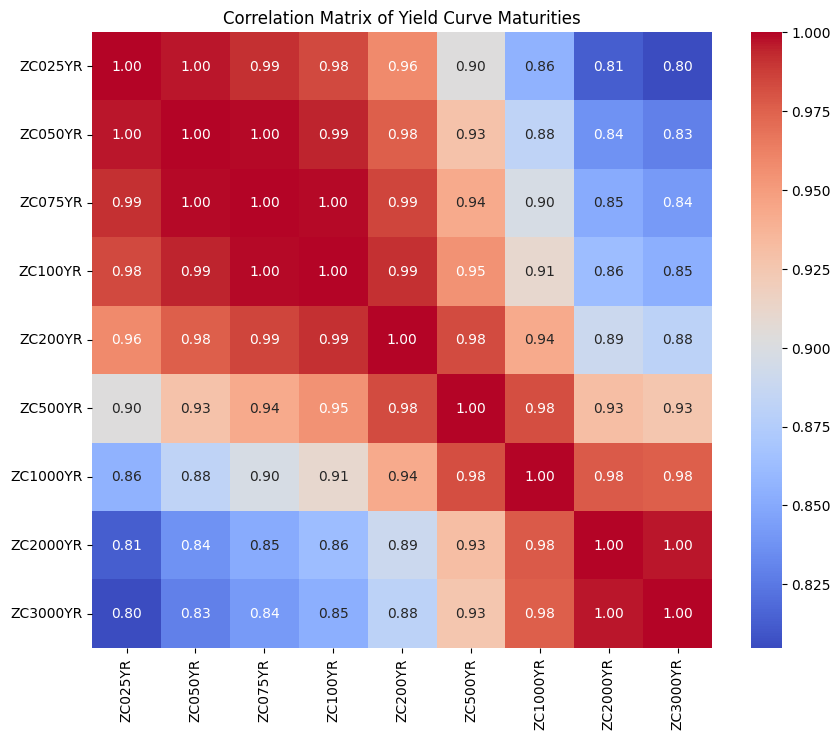

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

corr = train_df.iloc[:,1:].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Yield Curve Maturities")
plt.show()



The correlation matrix reveals strong positive relationships across all maturities, with correlations gradually declining as the maturity gap increases ( 1.00 for nearby maturities to approximately 0.80 for the 30-year tenor.) . The 3-Month yield remains highly correlated even with longer maturities, suggesting that a substantial portion of yield curve movements is driven by common underlying factors.

This observation supports the use of the short rate as the primary input in the CIR framework.


###4.2 Interest Rate Regimes

Since the 3-Month yield serves as the short rate in the CIR framework, it is useful to examine its behavior over time before model calibration.

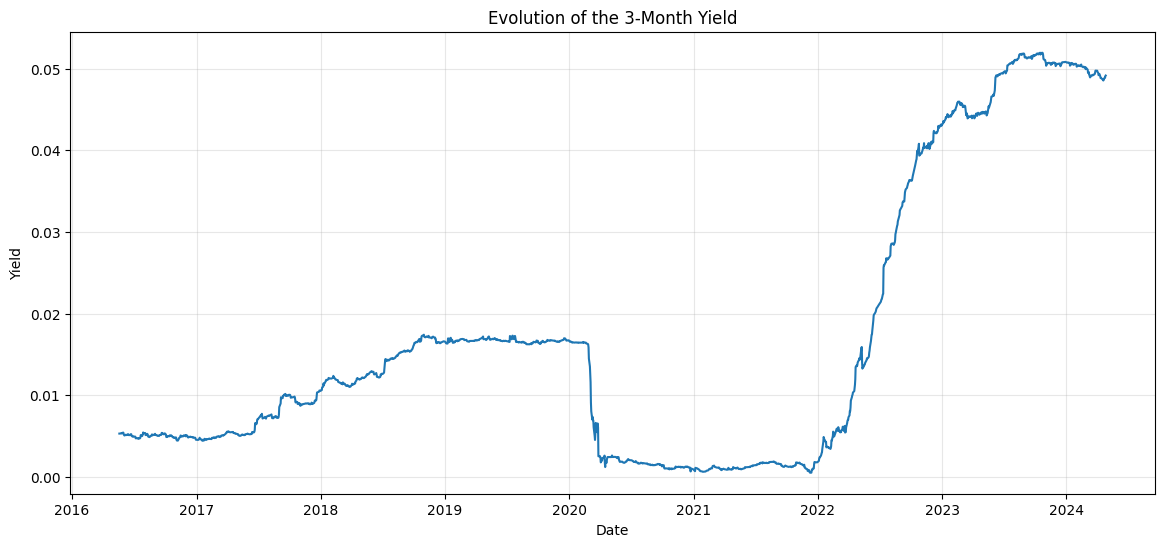

In [ ]:
plt.figure(figsize=(14,6))

plt.plot(
    train_df["Date"],
    train_df["ZC025YR"],
    linewidth=1.5
)

plt.title("Evolution of the 3-Month Yield")
plt.xlabel("Date")
plt.ylabel("Yield")

plt.grid(alpha=0.3)

plt.show()

The 3-Month yield exhibits distinct periods of low and high interest rates throughout the sample. In particular, prolonged low-rate periods are followed by a sharp increase in rates during the later part of the dataset.

These regime shifts suggest that the underlying interest-rate environment is not completely stable over time. As a result, parameter estimation based on the entire sample may be influenced by changing market conditions, an issue that becomes relevant during CIR calibration.

The sharp decline in rates around 2020 followed by the rapid increase after 2022 is consistent with major shifts in monetary policy, highlighting the presence of multiple market regimes within the sample.

###4.3 Yield Evolution



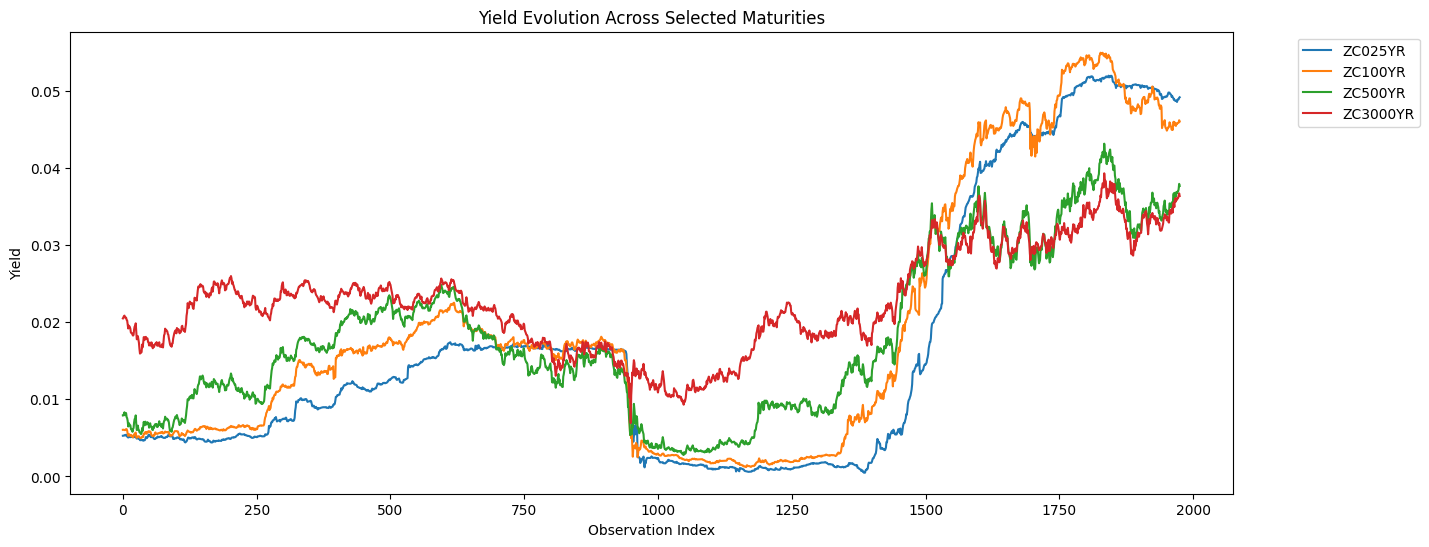

In [ ]:
plt.figure(figsize=(15,6))

selected_cols = [
    'ZC025YR',
    'ZC100YR',
    'ZC500YR',
    'ZC3000YR'
]
for col in selected_cols:
    plt.plot(train_df[col], label=col)

plt.title("Yield Evolution Across Selected Maturities")
plt.xlabel("Observation Index")
plt.ylabel("Yield")
plt.legend(bbox_to_anchor=(1.05,1))
plt.show()

The yield series exhibit strong co-movement through time, indicating that changes in market conditions affect the entire term structure simultaneously. Distinct low-rate and high-rate regimes are visible within the sample, reflecting changing economic and monetary policy environments.

Although the maturities move together, the magnitude of their responses differs across the curve. Short-term yields react more strongly to changing market conditions, while longer maturities exhibit smoother behavior.


###4.4 Distribution of the Short Rate

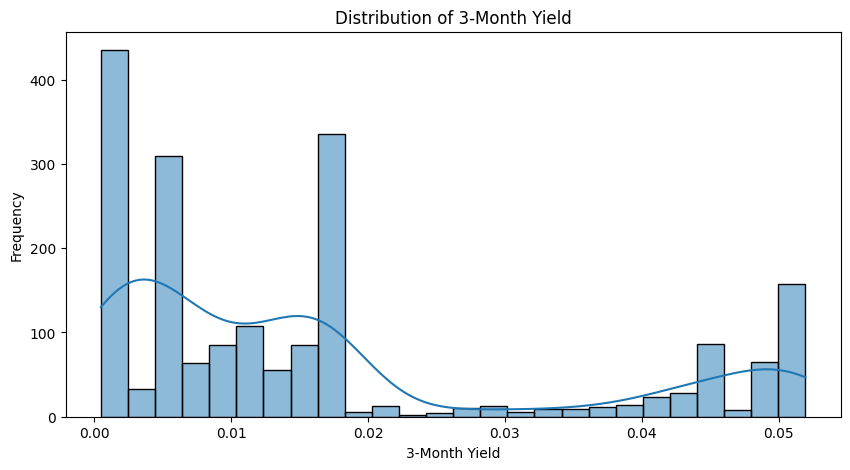

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(train_df['ZC025YR'], kde=True)
plt.title("Distribution of 3-Month Yield")
plt.xlabel("3-Month Yield")
plt.ylabel("Frequency")
plt.show()

The distribution of the 3-Month yield is positively skewed, with a large concentration of observations occurring at relatively low interest-rate levels. A smaller number of observations appear at higher yield levels, reflecting periods of monetary tightening.

The absence of negative yields is consistent with the assumptions of the CIR framework, which models interest rates as a non-negative process.

The bimodal appearance of the distribution reflects the coexistence of low-rate and high-rate environments observed in the regime analysis.

###4.5 Yield Curve Snapshots


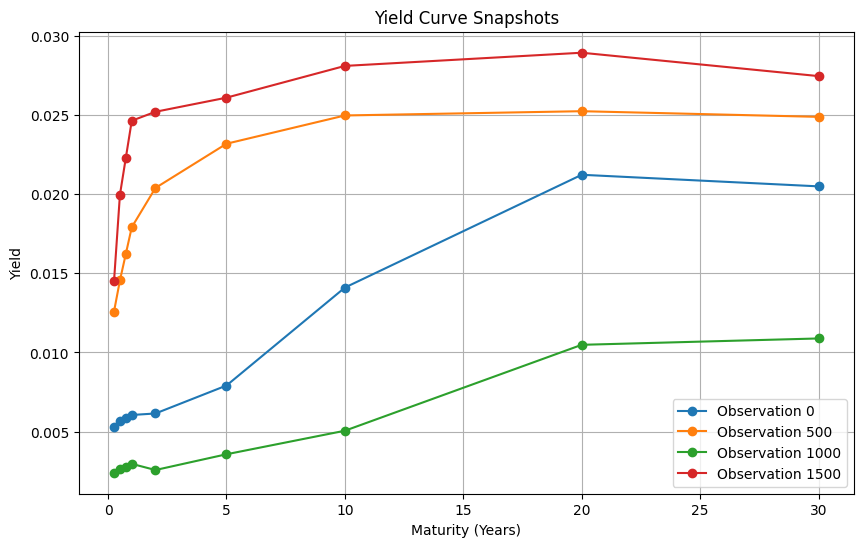

In [ ]:
maturities = [0.25,0.5,0.75,1,2,5,10,20,30]

rows = [0,500,1000,1500]

plt.figure(figsize=(10,6))

for row in rows:
    plt.plot(
        maturities,
        train_df.iloc[row,1:],
        marker='o',
        label=f'Observation {row}'
    )

plt.xlabel("Maturity (Years)")
plt.ylabel("Yield")
plt.title("Yield Curve Snapshots")
plt.legend()
plt.grid(True)
plt.show()

Yield curves sampled from different periods exhibit varying levels and slopes. While most observations display a traditional upward-sloping structure, the overall shape of the curve changes over time as market conditions evolve.

These variations indicate that although the yield curve is largely driven by common factors, changes in slope and curvature introduce additional complexity that may not be fully captured by a single-factor model.

In all sampled periods, the yield curve remains relatively smooth, suggesting that adjacent maturities are closely related. This smoothness supports the feasibility of reconstructing intermediate maturities from a short-rate model.

##4.6 EDA Summary

Three key observations emerge from the exploratory analysis:

1. Strong positive correlations exist across all maturities, indicating that movements in the yield curve are largely driven by common underlying factors.

2. Yield series exhibit substantial co-movement through time, suggesting that changes in market conditions affect the entire term structure simultaneously.

3. Yield curve snapshots show predominantly upward-sloping and smooth term structures, although the overall level and shape vary across different periods.

These findings support the use of the 3-Month yield as a proxy for the short rate and provide motivation for applying the CIR framework to reconstruct the remaining maturities.

#5. Cox-Ingersoll-Ross (CIR) Model

The CIR model assumes that the short-term interest rate follows a mean-reverting stochastic process:

$$
dr_t = \kappa(\theta-r_t)dt + \sigma\sqrt{r_t}dW_t
$$

where:

- $\kappa$ : speed of mean reversion
- $\theta$ : long-run mean interest rate
- $\sigma$ : volatility parameter
- $W_t$ : standard Brownian motion

The square-root diffusion term ensures that interest rates remain positive under suitable parameter conditions. The model satisfies the Feller condition:

$$
2\kappa\theta \geq \sigma^2
$$

which prevents the short rate from reaching negative values.

The CIR model admits a closed-form solution for zero-coupon bond pricing. The price of a bond maturing at time T can be expressed as:

$$
P(t,T)=A(t,T)e^{-B(t,T)r_t}
$$

where \(A(t,T)\) and \(B(t,T)\) are deterministic functions of the model parameters and maturity.

The corresponding continuously compounded yield is:


$$
y(t,T)
=
-\frac{\ln(P(t,T))}{T-t}
$$

In this project, the calibrated CIR parameters are first used to compute model-implied bond prices. These prices are then converted into yields and compared against observed market yields for evaluation.

Since the instantaneous short rate is not directly observable in market data, the 3-Month yield is used as a practical proxy. The exploratory analysis showed strong correlations between the 3-Month yield and longer maturities, supporting its use as the state variable in the CIR framework.

# 6. Calibration

### 6.1 Calibration Objective

The CIR model contains three unknown parameters:

- κ (speed of mean reversion)
- θ (long-run mean interest rate)
- σ (volatility)

These parameters cannot be directly observed from market data and must therefore be estimated through a calibration procedure.

The goal of calibration is to identify the parameter values that allow the CIR model to reproduce the observed yield curve as accurately as possible.

### 6.2 Why Full-Curve Calibration?

A straightforward approach would be to calibrate the CIR model using only the 3-Month yield, since it serves as the short-rate proxy.

However, the objective of this project is not merely to model the short rate, but to reconstruct the entire yield curve. Consequently, information from all available maturities should contribute to parameter estimation.

To capture the shape and dynamics of the full term structure, yields from 6 Months to 30 Years were incorporated into the calibration objective. This allows the estimated parameters to reflect behavior across both the short and long ends of the yield curve.

Since the evaluation dataset focuses primarily on shorter maturities (6M, 9M, 1Y and 2Y), higher weights were assigned to these maturities during optimization.

### 6.3 Calibration Methodology

The parameters were estimated using numerical optimization.

For each observation date, the observed 3-Month yield was treated as the short rate. Using a candidate parameter set (κ, θ, σ), the CIR bond pricing formula was used to generate model-implied yields across multiple maturities.

The optimization procedure then minimized the weighted mean squared error between observed market yields and model-implied yields.

$$
\text{Loss}
=
\frac{1}{N}
\sum_{i=1}^{N}
w_i
\left(
y_{\text{actual},i}
-
y_{\text{model},i}
\right)^2
$$

where wi denotes the maturity-specific weight used during calibration.

In [ ]:
train_calib = train_df.copy()

maturity_map = {
    "ZC050YR": 0.5,
    "ZC075YR": 0.75,
    "ZC100YR": 1,
    "ZC200YR": 2,
    "ZC500YR": 5,
    "ZC1000YR": 10,
    "ZC2000YR": 20,
    "ZC3000YR": 30
}

In [ ]:
import numpy as np


def cir_bond_price(r, kappa, theta, sigma, T):

    gamma = np.sqrt(kappa**2 + 2*sigma**2)

    A = (
        (
            2 * gamma *
            np.exp((kappa + gamma) * T / 2)
        )
        /
        (
            (kappa + gamma) *
            (np.exp(gamma * T) - 1)
            + 2 * gamma
        )
    ) ** (
        (2 * kappa * theta) / (sigma**2)
    )

    B = (
        2 * (np.exp(gamma * T) - 1)
    ) / (
        (kappa + gamma) *
        (np.exp(gamma * T) - 1)
        + 2 * gamma
    )

    return A * np.exp(-B * r)

In [ ]:
def objective(params):

    kappa, theta, sigma = params

    if kappa <= 0 or theta <= 0 or sigma <= 0:
        return 1e10

    if 2 * kappa * theta < sigma**2:
        return 1e10

    errors = []

    for i in range(len(train_calib)):

        r = train_calib.iloc[i]["ZC025YR"]

        for col, T in maturity_map.items():

            try:

                P = cir_bond_price(
                    r,
                    kappa,
                    theta,
                    sigma,
                    T
                )

                y_model = -np.log(P) / T

                y_actual = train_calib.iloc[i][col]

                if T <= 2:
                    weight = 5
                else:
                    weight = 1

                errors.append(
                    weight *
                    (y_actual - y_model) ** 2
                )

            except:
                return 1e10

    return np.mean(errors)

### 6.4 Parameter Constraints

To ensure economically meaningful parameter estimates, the following constraints were imposed during optimization:

- κ > 0
- θ > 0
- σ > 0

In addition, the Feller condition was enforced:

$$
2\kappa\theta \geq \sigma^2
$$

This condition guarantees positivity of the short-rate process and is one of the key theoretical properties of the CIR model.

### 6.5 Optimization Procedure

The parameter estimation problem was formulated as a constrained nonlinear optimization problem.

The L-BFGS-B algorithm was selected because it efficiently handles bound constraints while remaining computationally tractable for large datasets.

The optimization searches for parameter values that minimize the weighted loss function while satisfying the positivity and Feller constraints.

In [ ]:
from scipy.optimize import minimize

initial_guess = [
    0.20,
    0.02,
    0.03
]

bounds = [
    (0.001, 5),
    (0.001, 0.20),
    (0.001, 0.50)
]

result = minimize(
    objective,
    initial_guess,
    method="L-BFGS-B",
    bounds=bounds
)

kappa_full, theta_full, sigma_full = result.x

print("Optimized Parameters")
print("--------------------")
print("Kappa :", round(kappa_full, 6))
print("Theta :", round(theta_full, 6))
print("Sigma :", round(sigma_full, 6))

print("\nFeller Check")
print(
    2 * kappa_full * theta_full,
    ">=",
    sigma_full**2
)

Optimized Parameters
--------------------
Kappa : 0.172544
Theta : 0.02526
Sigma : 0.031895

Feller Check
0.008717058485323757 >= 0.0010173096838021452


### 6.6 Estimated Parameters

The optimization procedure produced the following parameter estimates:

- κ = 0.1725
- θ = 0.0253
- σ = 0.0319

The estimated value of κ indicates a moderate tendency of interest rates to revert toward their long-run mean.

The estimated θ represents the long-run equilibrium level of interest rates implied by the historical yield curve.

The volatility parameter σ captures the magnitude of random fluctuations in the short rate process.

The satisfaction of the Feller condition confirms that the calibrated CIR process remains strictly positive, which is one of the key theoretical advantages of the model.

# 7. Yield Curve Reconstruction

### 7.1 Reconstruction Methodology

After calibrating the CIR parameters, the model is used to reconstruct the yield curve using only the observed 3-Month yield as input.

For each observation in the test dataset:

1. The 3-Month yield is treated as the short rate.
2. The CIR bond pricing formula is used to compute zero-coupon bond prices.
3. Bond prices are converted into model-implied yields.
4. The process is repeated for all target maturities.

The resulting yields represent the CIR model's estimate of the term structure.

###7.2 Reconstructed Yield Generation
Using the calibrated parameters obtained from the training dataset, model-implied yields are generated for each observation in the test set.

For every observed 3-Month yield, the CIR bond pricing formula is used to compute zero-coupon bond prices for the target maturities. These bond prices are then converted into continuously compounded yields.

The resulting predictions form the reconstructed yield curve used for performance evaluation.

In [ ]:
predictions_full = pd.DataFrame()

target_maturities = {
    "ZC050YR":0.5,
    "ZC075YR":0.75,
    "ZC100YR":1,
    "ZC200YR":2
}

for col, T in target_maturities.items():

    preds = []

    for r in test_3m_df["ZC025YR"]:

        P = cir_bond_price(
            r,
            kappa_full,
            theta_full,
            sigma_full,
            T
        )

        y = -np.log(P) / T

        preds.append(y)

    predictions_full[col] = preds

###7.3 Sample Reconstruction Yields
The table below presents a sample of the reconstructed yields generated by the calibrated CIR model.

In [ ]:
predictions_full.head()

,ZC050YR,ZC075YR,ZC100YR,ZC200YR
0,0.048141,0.047659,0.047190,0.045434
1,0.048153,0.047671,0.047201,0.045445
2,0.048099,0.047618,0.047150,0.045397
3,0.047927,0.047450,0.046985,0.045245
4,0.047651,0.047180,0.046721,0.045002


# 8. Evaluation

###8.1 Overall Performance
To evaluate predictive performance, actual and predicted yields were flattened across all target maturities and observations.

The coefficient of determination (R²) was then computed.

In [ ]:
from sklearn.metrics import r2_score

y_true = test_df[
    [
        "ZC050YR",
        "ZC075YR",
        "ZC100YR",
        "ZC200YR"
    ]
].values.flatten()

y_pred = predictions_full[
    [
        "ZC050YR",
        "ZC075YR",
        "ZC100YR",
        "ZC200YR"
    ]
].values.flatten()

overall_r2 = r2_score(
    y_true,
    y_pred
)

print("Overall R² =", round(overall_r2, 4))

Overall R² = 0.8939


###8.2 Maturity-wise Performance

In [ ]:
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

import numpy as np

for col in target_maturities:

    r2 = r2_score(
        test_df[col],
        predictions_full[col]
    )

    rmse = np.sqrt(
        mean_squared_error(
            test_df[col],
            predictions_full[col]
        )
    )

    mae = mean_absolute_error(
        test_df[col],
        predictions_full[col]
    )

    print(f"\n{col}")
    print(f"R²   : {r2:.4f}")
    print(f"RMSE : {rmse:.6f}")
    print(f"MAE  : {mae:.6f}")


ZC050YR
R²   : 0.9944
RMSE : 0.000588
MAE  : 0.000431

ZC075YR
R²   : 0.9675
RMSE : 0.001302
MAE  : 0.000973

ZC100YR
R²   : 0.9104
RMSE : 0.001970
MAE  : 0.001477

ZC200YR
R²   : 0.3965
RMSE : 0.003634
MAE  : 0.002784


The CIR model captures the general level and slope of the yield curve, particularly at shorter maturities. However, deviations become increasingly visible as maturity increases, highlighting the limitations of the single-factor assumption.

###8.3 Actual vs Predicted Yield Comparison

To visually assess model performance, actual and predicted yields are compared for the longest maturity in the test dataset.

The 2-Year maturity is selected because it represents the most challenging tenor for the single-factor CIR model.

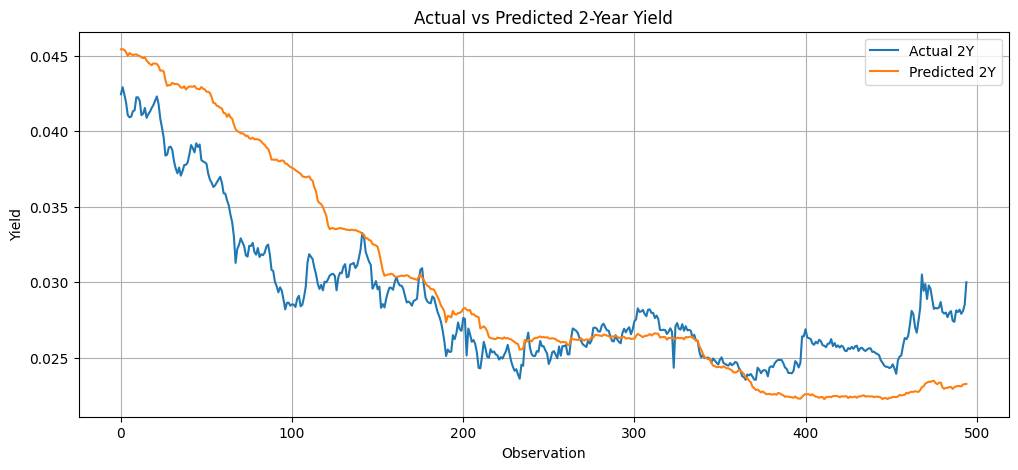

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(
    test_df["ZC200YR"].values,
    label="Actual 2Y"
)

plt.plot(
    predictions_full["ZC200YR"].values,
    label="Predicted 2Y"
)

plt.title("Actual vs Predicted 2-Year Yield")
plt.xlabel("Observation")
plt.ylabel("Yield")
plt.legend()
plt.grid(True)

plt.show()

### 8.4 Yield Curve Shape Comparison

While numerical metrics such as R², RMSE, and MAE quantify prediction accuracy, they do not fully capture the model's ability to reproduce the overall shape of the yield curve.

To evaluate this aspect, actual and reconstructed yield curves are compared for selected observations from the test dataset. The comparison focuses on the level and slope of the term structure across maturities ranging from 3 Months to 2 Years.

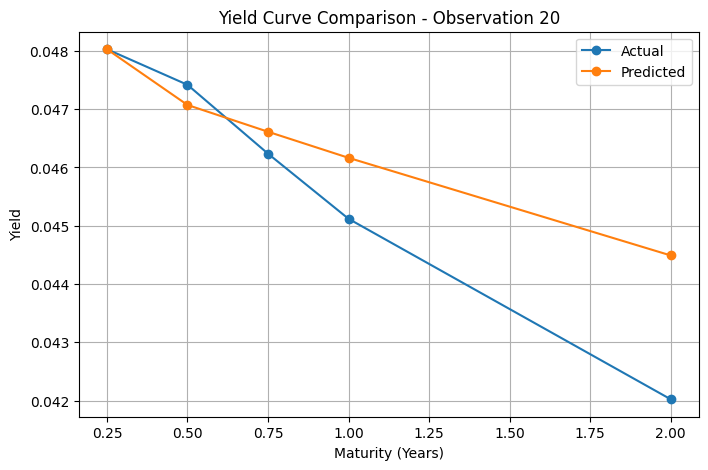

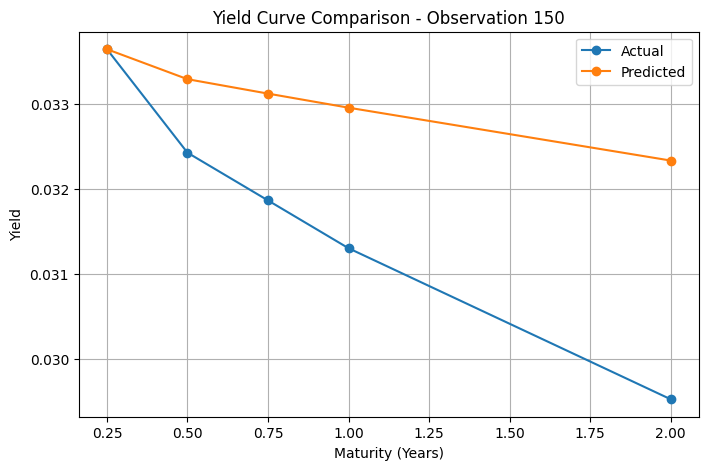

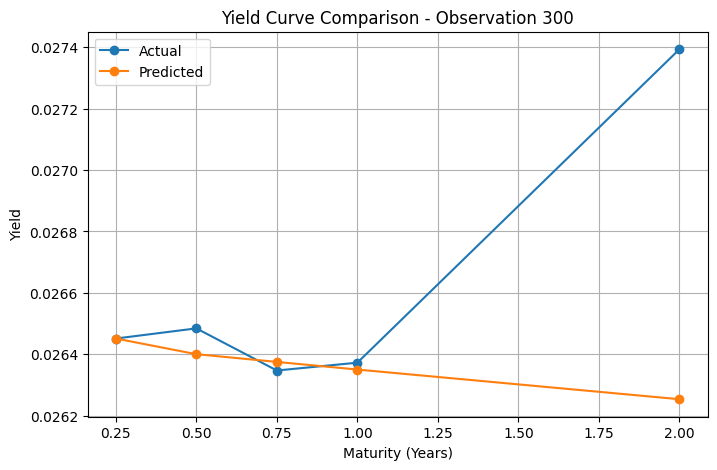

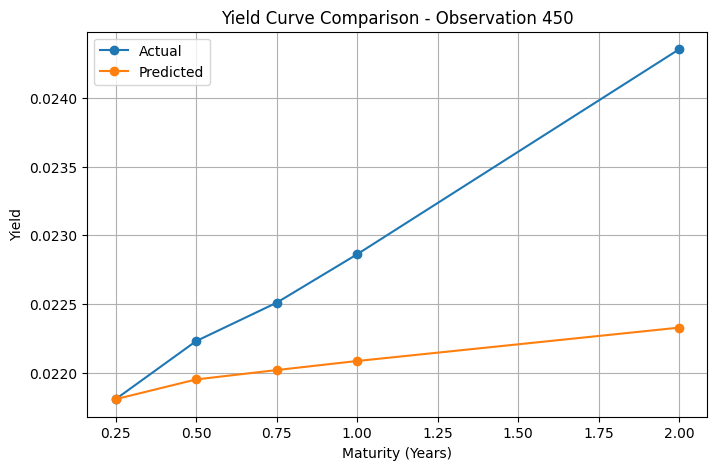

In [ ]:
import matplotlib.pyplot as plt

maturities = [0.25, 0.5, 0.75, 1, 2]

rows = [20, 150, 300, 450]

for row in rows:

    actual_curve = [
        test_3m_df.iloc[row]["ZC025YR"],
        test_df.iloc[row]["ZC050YR"],
        test_df.iloc[row]["ZC075YR"],
        test_df.iloc[row]["ZC100YR"],
        test_df.iloc[row]["ZC200YR"]
    ]

    predicted_curve = [
        test_3m_df.iloc[row]["ZC025YR"],   # actual 3M input
        predictions_full.iloc[row]["ZC050YR"],
        predictions_full.iloc[row]["ZC075YR"],
        predictions_full.iloc[row]["ZC100YR"],
        predictions_full.iloc[row]["ZC200YR"]
    ]

    plt.figure(figsize=(8,5))

    plt.plot(
        maturities,
        actual_curve,
        marker='o',
        label='Actual'
    )

    plt.plot(
        maturities,
        predicted_curve,
        marker='o',
        label='Predicted'
    )

    plt.title(f"Yield Curve Comparison - Observation {row}")
    plt.xlabel("Maturity (Years)")
    plt.ylabel("Yield")
    plt.legend()
    plt.grid(True)

    plt.show()

The reconstructed yield curves closely follow the observed term structure across most observations. The model successfully captures the overall level and slope of the yield curve, particularly at shorter maturities.

Minor deviations become more visible at the 2-Year maturity, reflecting the limitations of a single-factor interest rate model. Nevertheless, the CIR framework provides a reasonable approximation of the yield curve shape using only the observed 3-Month yield as input.

###8.5 Discussion
The calibrated CIR model achieves an overall R² of 0.8939, exceeding the project benchmark of 0.85.

Performance is strongest at shorter maturities, with R² values above 0.90 for the 6-Month, 9-Month, and 1-Year yields. This indicates that the 3-Month yield contains substantial information about nearby points on the yield curve.

Performance deteriorates for the 2-Year maturity, where additional market expectations and risk premia become more important. Since the CIR model relies on a single stochastic factor, its ability to explain longer-term yield dynamics is naturally limited.

Despite this limitation, the reconstructed yield curves closely follow the observed term structure and successfully capture the overall level and slope of interest rates.

The decline in performance at the 2-Year maturity suggests that a single-factor short-rate model is insufficient to fully capture medium-term yield dynamics, motivating the exploration of CIR++ and other multi-factor extensions.

# 9. CIR++ Extension



###9.1 Motivation
Although the calibrated CIR model achieved strong predictive performance, it remains a single-factor short-rate model. Such models may struggle to fully capture the shape of the observed yield curve because they assume that all maturities are driven by the same underlying factor.

To improve flexibility, a CIR++ extension is considered. CIR++ augments the original CIR process with a deterministic shift function that allows the model to better match the observed term structure while preserving the desirable mean-reverting and positivity properties of the CIR framework.

### 9.2 CIR++ Framework

The CIR++ model extends the base CIR framework by introducing a deterministic shift function that adjusts the model-implied yields.

The reconstructed CIR++ yield is given by:

$$
y^{CIR++}(T)=y^{CIR}(T)+s(T)
$$

where:

- $y^{CIR}(T)$ is the yield generated by the calibrated CIR model
- $s(T)$ is a maturity-specific deterministic shift
- $y^{CIR++}(T)$ is the adjusted yield

The shift is estimated using the average historical spread between each maturity and the 3-Month yield in the training dataset.

###9.3 CIR++ Reconstruction



In [ ]:
# Estimate average historical spreads

spread_6m = (
    train_df["ZC050YR"] -
    train_df["ZC025YR"]
).mean()

spread_9m = (
    train_df["ZC075YR"] -
    train_df["ZC025YR"]
).mean()

spread_1y = (
    train_df["ZC100YR"] -
    train_df["ZC025YR"]
).mean()

spread_2y = (
    train_df["ZC200YR"] -
    train_df["ZC025YR"]
).mean()

print("6M Spread :", round(spread_6m,6))
print("9M Spread :", round(spread_9m,6))
print("1Y Spread :", round(spread_1y,6))
print("2Y Spread :", round(spread_2y,6))


# Create CIR++ predictions

cirpp_predictions = predictions_full.copy()

cirpp_predictions["ZC050YR"] += spread_6m
cirpp_predictions["ZC075YR"] += spread_9m
cirpp_predictions["ZC100YR"] += spread_1y
cirpp_predictions["ZC200YR"] += spread_2y

cirpp_predictions.head()

6M Spread : 0.001186
9M Spread : 0.00183
1Y Spread : 0.002475
2Y Spread : 0.001364


,ZC050YR,ZC075YR,ZC100YR,ZC200YR
0,0.049328,0.049490,0.049666,0.046798
1,0.049339,0.049501,0.049677,0.046809
2,0.049286,0.049449,0.049625,0.046761
3,0.049113,0.049280,0.049460,0.046609
4,0.048838,0.049010,0.049196,0.046366


###9.4 CIR++ Performance

In [ ]:
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)

import numpy as np
import pandas as pd

results_cirpp = []

for col in [
    "ZC050YR",
    "ZC075YR",
    "ZC100YR",
    "ZC200YR"
]:

    r2 = r2_score(
        test_df[col],
        cirpp_predictions[col]
    )

    rmse = np.sqrt(
        mean_squared_error(
            test_df[col],
            cirpp_predictions[col]
        )
    )

    mae = mean_absolute_error(
        test_df[col],
        cirpp_predictions[col]
    )

    results_cirpp.append([
        col,
        r2,
        rmse,
        mae
    ])

cirpp_results = pd.DataFrame(
    results_cirpp,
    columns=[
        "Maturity",
        "R2",
        "RMSE",
        "MAE"
    ]
)

cirpp_results



,Maturity,R2,RMSE,MAE
0,ZC050YR,0.965798,0.001457,0.001344
1,ZC075YR,0.869719,0.002606,0.002322
2,ZC100YR,0.691100,0.003658,0.003197
3,ZC200YR,0.204133,0.004172,0.003264


In [ ]:
comparison = pd.DataFrame({
    "Maturity":["6M","9M","1Y","2Y"],
    "CIR_R2":[0.9944,0.9675,0.9104,0.3965],
    "CIR++_R2":[0.9658,0.8697,0.6911,0.2041]
})

comparison

,Maturity,CIR_R2,CIR++_R2
0,6M,0.9944,0.9658
1,9M,0.9675,0.8697
2,1Y,0.9104,0.6911
3,2Y,0.3965,0.2041


The deterministic-shift CIR++ extension was evaluated to determine whether a maturity-specific adjustment could improve the predictive performance of the calibrated CIR model.

The results indicate that CIR++ underperformed the base CIR model across all maturities. While the deterministic shift successfully adjusts the average level of yields, it fails to account for the time-varying nature of yield spreads observed in the data.

The deterioration in performance suggests that the relationship between the short rate and longer maturities changes across market regimes and therefore cannot be adequately represented by a constant maturity-specific adjustment.

Consequently, the calibrated CIR model remains the best-performing model in this study.

#10. Model Comparison


###10.1 CIR vs Linear Regression

To provide a benchmark for the CIR framework, a simple Linear Regression model was also evaluated. The model uses only the observed 3-Month yield as input and predicts the target maturities directly. Unlike CIR, Linear Regression does not incorporate any assumptions regarding interest-rate dynamics, mean reversion, or term structure behavior. The comparison therefore highlights the value of financial modeling relative to a purely statistical approach.


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import pandas as pd
import matplotlib.pyplot as plt

maturities = [
    "ZC050YR",
    "ZC075YR",
    "ZC100YR",
    "ZC200YR"
]

lr_r2 = []
cir_r2 = []

for col in maturities:

    # Train Linear Regression
    X_train = train_df[["ZC025YR"]]
    y_train = train_df[col]

    model = LinearRegression()
    model.fit(X_train, y_train)

    # Predict on test set
    X_test = test_3m_df[["ZC025YR"]]
    y_pred = model.predict(X_test)

    # Calculate R²
    lr_r2.append(
        r2_score(test_df[col], y_pred)
    )

# CIR R² values from evaluation section
for col in maturities:

    cir_r2.append(
        r2_score(
            test_df[col],
            predictions_full[col]
        )
    )

comparison_df = pd.DataFrame({
    "Maturity": ["6M", "9M", "1Y", "2Y"],
    "Linear Regression R²": lr_r2,
    "CIR R²": cir_r2
})

comparison_df["Difference"] = (
    comparison_df["CIR R²"] -
    comparison_df["Linear Regression R²"]
)

comparison_df

,Maturity,Linear Regression R²,CIR R²,Difference
0,6M,0.947026,0.994441,0.047415
1,9M,0.831577,0.967493,0.135916
2,1Y,0.628338,0.910350,0.282012
3,2Y,0.551488,0.396456,-0.155032


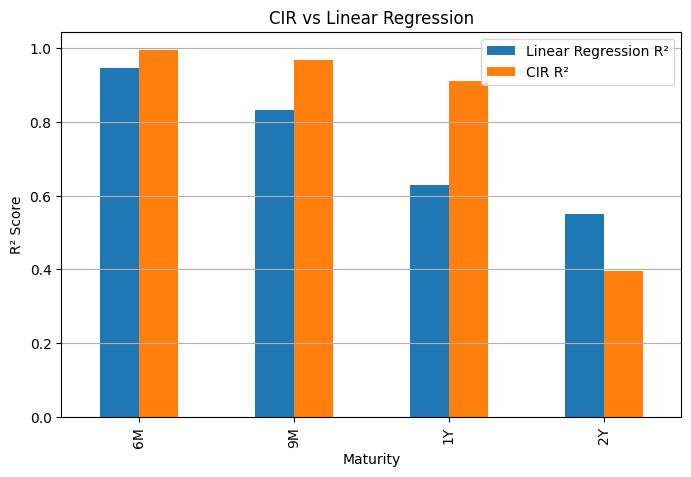

In [ ]:
comparison_df.set_index("Maturity")[
    ["Linear Regression R²", "CIR R²"]
].plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("CIR vs Linear Regression")
plt.ylabel("R² Score")
plt.grid(axis="y")
plt.show()

###10.2 Discussion
Although Linear Regression performs competitively at certain maturities, it lacks any economic interpretation and does not explicitly model interest-rate dynamics.

In contrast, the CIR framework incorporates economically meaningful concepts such as mean reversion, stochastic evolution of short rates, and positivity constraints. The strong predictive performance achieved by the calibrated CIR model demonstrates that incorporating financial structure can provide significant benefits over purely statistical approaches.

# 11. Limitations of the CIR Model

Despite its strengths, the CIR model has several limitations:

• Single-factor structure restricts flexibility in fitting complex yield curve movements.

• Medium and long-term maturities may be influenced by factors not captured by the short rate alone.

• Volatility is assumed to follow a specific functional form.

• The model cannot perfectly reproduce arbitrary market yield curves.

• Calibration results may vary across different market regimes.

These limitations motivate the use of more advanced frameworks such as CIR++ and multi-factor CIR models.

# 12. Conclusion

This project implemented and evaluated the Cox-Ingersoll-Ross (CIR) interest rate model using historical zero-coupon yield data.

After exploratory analysis and parameter calibration, the CIR model was used to reconstruct the yield curve using only the observed 3-Month yield as input. Full-curve calibration across maturities up to 30 years produced an overall out-of-sample R² of 0.8939, exceeding the project benchmark of 0.85.

The model successfully captured the overall level and slope of the yield curve, particularly at shorter maturities. Although performance declined for the 2-Year maturity, the results demonstrate that a parsimonious short-rate model can still provide strong predictive capability when appropriately calibrated.

A CIR++ extension was also explored. However, the deterministic-shift implementation did not improve predictive performance, indicating that yield spreads vary through time and cannot be adequately represented using constant maturity-specific adjustments.

Overall, the calibrated CIR model emerged as the best-performing and most economically interpretable framework considered in this study, illustrating the practical applicability of stochastic short-rate models for yield curve reconstruction.
